# Credit Card Customer Segmentation

**Goal:** take a credit card customer dataset and find the natural groups of customers inside it, then build a model that can put a new customer into the right group.

**The data:** ~8,950 credit card holders, 17 behaviour features (balance, purchases, cash advance, payments, etc.). It is a public dataset from Kaggle (*Credit Card Dataset for Clustering*).

**What I do here:**
1. clean the data
2. quick look at the distributions and correlations
3. transform + scale the features
4. K-Means clustering, and choose K with the elbow and silhouette
5. cross check the groups with a second clustering method
6. describe each group in business terms
7. train two classifiers to predict the group (Decision Tree and Random Forest)


In [3]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

from sklearn.preprocessing import StandardScaler
from sklearn.cluster import KMeans, AgglomerativeClustering
from sklearn.metrics import silhouette_score, adjusted_rand_score
from sklearn.decomposition import PCA
from sklearn.model_selection import train_test_split
from sklearn.tree import DecisionTreeClassifier, plot_tree
from sklearn.ensemble import RandomForestClassifier
from sklearn.metrics import (accuracy_score, cohen_kappa_score,
                             confusion_matrix, classification_report)

RANDOM_STATE = 42
sns.set_theme(style="whitegrid")
pd.set_option("display.max_columns", 30)

## 1. Load and clean the data

First I drop `CUST_ID` (it is only an id, no information for grouping).

Two columns have missing values: `MINIMUM_PAYMENTS` (313 rows) and `CREDIT_LIMIT` (1 row). Both are money columns and they are right skewed, so I fill them with the **median** instead of the mean. The mean would be pulled up by the few very large customers.

In [4]:
df = pd.read_csv("../data/credit_card_customers.csv")
print("raw shape:", df.shape)

df = df.drop(columns=["CUST_ID"])

for col in ["MINIMUM_PAYMENTS", "CREDIT_LIMIT"]:
    n = df[col].isna().sum()
    df[col] = df[col].fillna(df[col].median())
    print(f"filled {n} missing in {col}")

features = df.columns.tolist()
print("features:", len(features))
df.head()

raw shape: (8950, 18)
filled 313 missing in MINIMUM_PAYMENTS
filled 1 missing in CREDIT_LIMIT
features: 17


,BALANCE,BALANCE_FREQUENCY,PURCHASES,ONEOFF_PURCHASES,INSTALLMENTS_PURCHASES,CASH_ADVANCE,PURCHASES_FREQUENCY,ONEOFF_PURCHASES_FREQUENCY,PURCHASES_INSTALLMENTS_FREQUENCY,CASH_ADVANCE_FREQUENCY,CASH_ADVANCE_TRX,PURCHASES_TRX,CREDIT_LIMIT,PAYMENTS,MINIMUM_PAYMENTS,PRC_FULL_PAYMENT,TENURE
0,40.900749,0.818182,95.40,0.00,95.4,0.000000,0.166667,0.000000,0.083333,0.000000,0,2,1000.0,201.802084,139.509787,0.000000,12
1,3202.467416,0.909091,0.00,0.00,0.0,6442.945483,0.000000,0.000000,0.000000,0.250000,4,0,7000.0,4103.032597,1072.340217,0.222222,12
2,2495.148862,1.000000,773.17,773.17,0.0,0.000000,1.000000,1.000000,0.000000,0.000000,0,12,7500.0,622.066742,627.284787,0.000000,12
3,1666.670542,0.636364,1499.00,1499.00,0.0,205.788017,0.083333,0.083333,0.000000,0.083333,1,1,7500.0,0.000000,312.343947,0.000000,12
4,817.714335,1.000000,16.00,16.00,0.0,0.000000,0.083333,0.083333,0.000000,0.000000,0,1,1200.0,678.334763,244.791237,0.000000,12


## 2. A quick look (EDA)

Below are the distributions of four important money features. They are all strongly right skewed - most customers have low values and a small number have very high values. This is a normal shape for spending data but it is the reason I will use a log transform later.

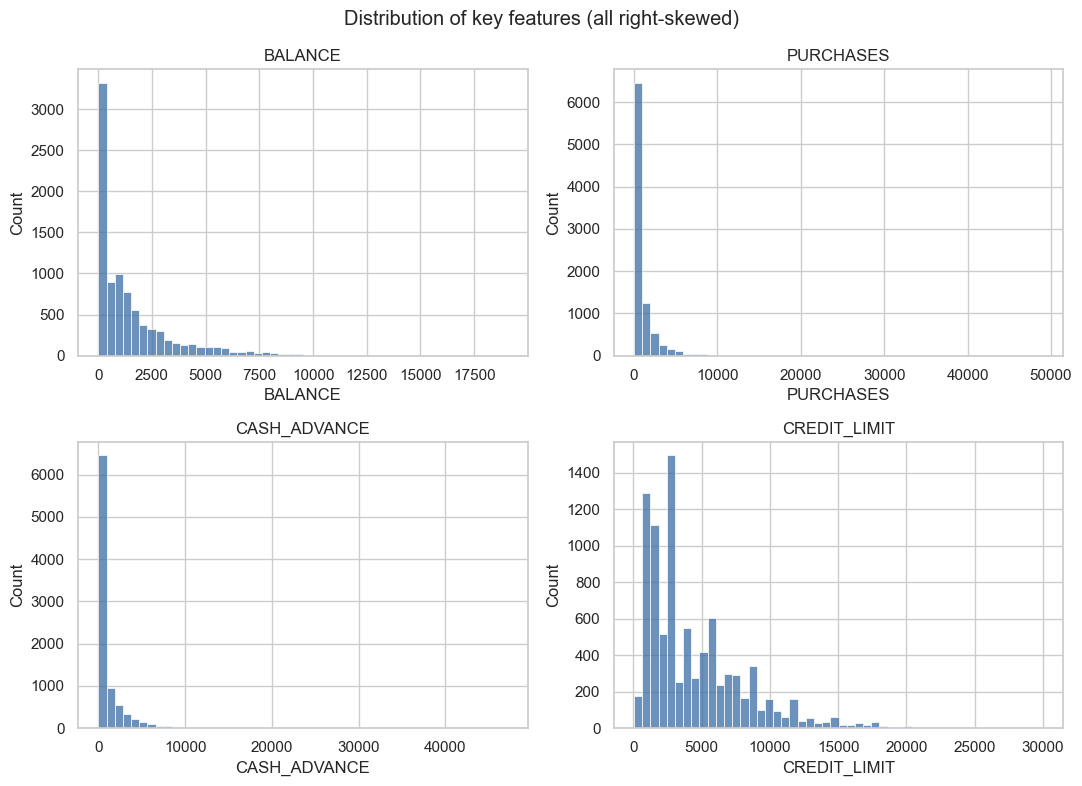

In [5]:
key_vars = ["BALANCE", "PURCHASES", "CASH_ADVANCE", "CREDIT_LIMIT"]
fig, axes = plt.subplots(2, 2, figsize=(11, 8))
for ax, col in zip(axes.ravel(), key_vars):
    sns.histplot(df[col], bins=50, ax=ax, color="#3b6ea5")
    ax.set_title(col)
fig.suptitle("Distribution of key features (all right-skewed)")
plt.tight_layout(); plt.show()

Now the correlation between the features. A few pairs are clearly linked:

- `PURCHASES` and `PURCHASES_TRX` move together (more spending = more transactions).
- `CASH_ADVANCE` and `CASH_ADVANCE_TRX` / `CASH_ADVANCE_FREQUENCY` are linked (people who take cash advance do it repeatedly).
- `PRC_FULL_PAYMENT` is negatively related to balance (people who pay in full carry less balance).

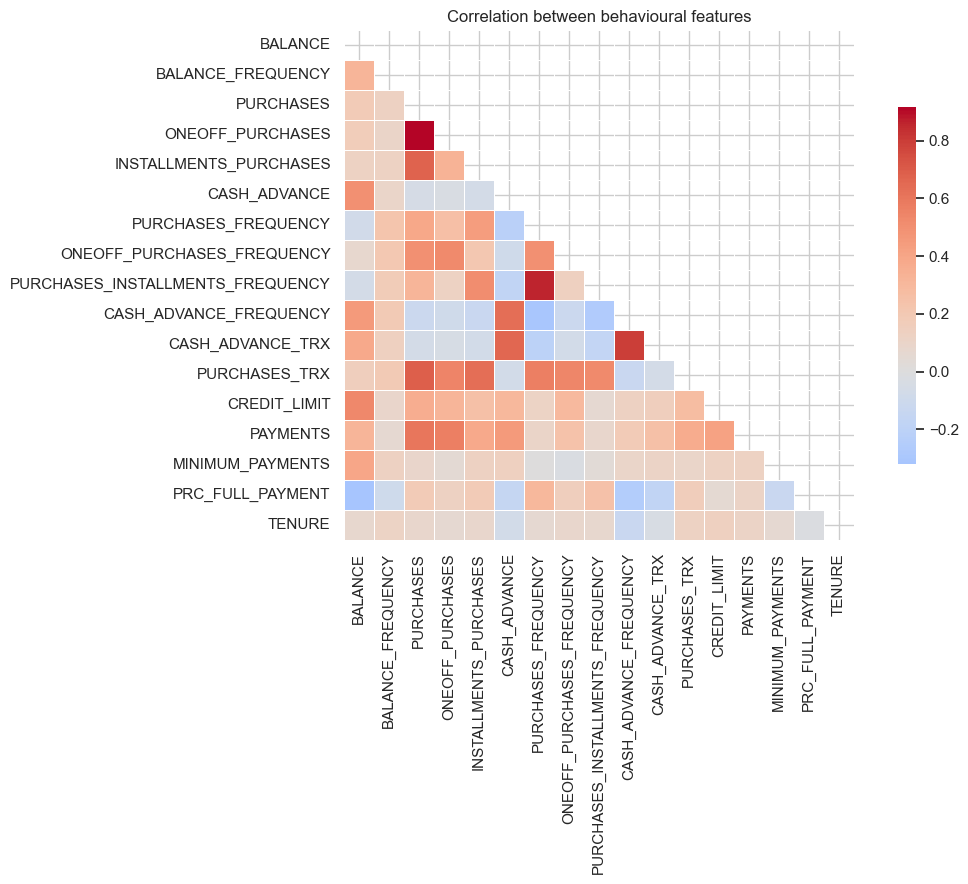

In [6]:
plt.figure(figsize=(12, 9))
corr = df.corr()
mask = np.triu(np.ones_like(corr, dtype=bool))
sns.heatmap(corr, mask=mask, cmap="coolwarm", center=0,
            square=True, linewidths=.4, cbar_kws={"shrink": .7})
plt.title("Correlation between behavioural features")
plt.tight_layout(); plt.show()

## 3. Transform and scale

K-Means works on Euclidean distance, so two things matter:

1. **Skew** - a few huge customers can dominate the distance. So I apply `log1p` (which is `log(1+x)`, it also handles zeros) to the columns that are clearly skewed.
2. **Scale** - features are on very different scales (balance in thousands, frequencies between 0 and 1). I use z-score so every feature has mean 0 and std 1 and contributes equally.

In [7]:
skewed = [c for c in features if df[c].skew() > 1.0]
print("log-transforming:", skewed)

df_t = df.copy()
for col in skewed:
    df_t[col] = np.log1p(df_t[col])

scaler = StandardScaler()
X = pd.DataFrame(scaler.fit_transform(df_t), columns=features)
X.describe().round(2).loc[["mean", "std"]]

log-transforming: ['BALANCE', 'PURCHASES', 'ONEOFF_PURCHASES', 'INSTALLMENTS_PURCHASES', 'CASH_ADVANCE', 'ONEOFF_PURCHASES_FREQUENCY', 'CASH_ADVANCE_FREQUENCY', 'CASH_ADVANCE_TRX', 'PURCHASES_TRX', 'CREDIT_LIMIT', 'PAYMENTS', 'MINIMUM_PAYMENTS', 'PRC_FULL_PAYMENT']


,BALANCE,BALANCE_FREQUENCY,PURCHASES,ONEOFF_PURCHASES,INSTALLMENTS_PURCHASES,CASH_ADVANCE,PURCHASES_FREQUENCY,ONEOFF_PURCHASES_FREQUENCY,PURCHASES_INSTALLMENTS_FREQUENCY,CASH_ADVANCE_FREQUENCY,CASH_ADVANCE_TRX,PURCHASES_TRX,CREDIT_LIMIT,PAYMENTS,MINIMUM_PAYMENTS,PRC_FULL_PAYMENT,TENURE
mean,0.0,0.0,0.0,0.0,0.0,0.0,-0.0,0.0,0.0,-0.0,-0.0,0.0,-0.0,0.0,-0.0,-0.0,0.0
std,1.0,1.0,1.0,1.0,1.0,1.0,1.0,1.0,1.0,1.0,1.0,1.0,1.0,1.0,1.0,1.0,1.0


## 4. How many clusters? (choosing K)

I run K-Means for K from 2 to 10 and look at two things:

- **Elbow** - the within-cluster sum of squares (how tight the clusters are). It always goes down with more K, I look for the bend.
- **Silhouette** - how well each point fits its own cluster vs the others (higher is better). I compute it on a sample of 2,000 points because it is slow on the full data.

Both together point me to **K = 4**, which is also a number that is easy to explain to a business audience.

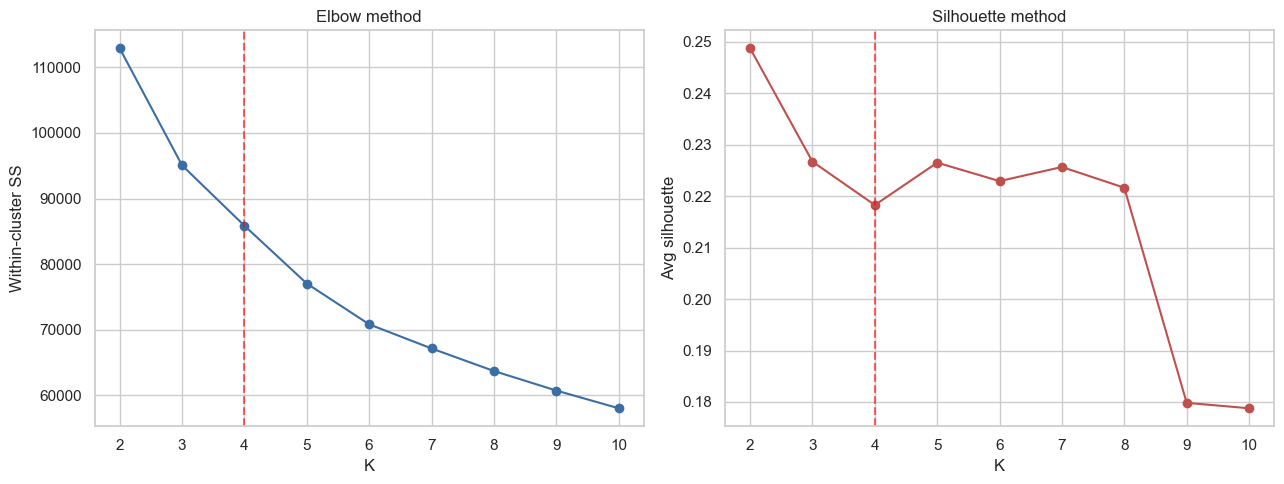

In [8]:
wss, sil = [], []
k_range = range(2, 11)
sample_idx = np.random.RandomState(RANDOM_STATE).choice(len(X), 2000, replace=False)

for k in k_range:
    km = KMeans(n_clusters=k, n_init=25, max_iter=300, random_state=RANDOM_STATE)
    labels = km.fit_predict(X)
    wss.append(km.inertia_)
    sil.append(silhouette_score(X.iloc[sample_idx], labels[sample_idx]))

fig, ax = plt.subplots(1, 2, figsize=(13, 5))
ax[0].plot(list(k_range), wss, "o-", color="#3b6ea5")
ax[0].axvline(4, color="red", ls="--", alpha=.6)
ax[0].set(title="Elbow method", xlabel="K", ylabel="Within-cluster SS")
ax[1].plot(list(k_range), sil, "o-", color="#c0504d")
ax[1].axvline(4, color="red", ls="--", alpha=.6)
ax[1].set(title="Silhouette method", xlabel="K", ylabel="Avg silhouette")
plt.tight_layout(); plt.show()

## 5. Fit K-Means, and cross-check with a second method

I fit the final K-Means with K = 4. Then I run a completely different method (hierarchical / Agglomerative) on a sample and check the agreement with the **adjusted Rand index**. The idea is simple: if the groups are real, a second method should find something similar. A perfect match is 1.0 and a random match is around 0. I get a moderate agreement, which tells me the structure is there but the borders between some groups are soft (this is also visible later in the PCA plot).

agreement K-Means vs Hierarchical (adjusted Rand): 0.495
cluster
0    2414
1    1518
2    1906
3    3112
Name: count, dtype: int64


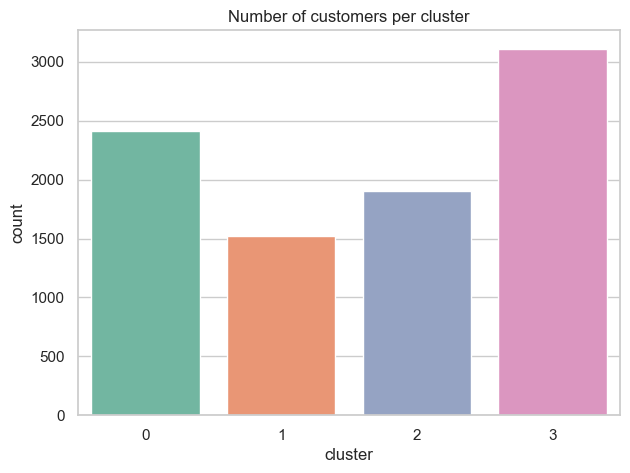

In [9]:
kmeans = KMeans(n_clusters=4, n_init=25, max_iter=300, random_state=RANDOM_STATE)
df["cluster"] = kmeans.fit_predict(X)

agg = AgglomerativeClustering(n_clusters=4)
agg_labels = agg.fit_predict(X.iloc[sample_idx])
agree = adjusted_rand_score(df["cluster"].values[sample_idx], agg_labels)
print(f"agreement K-Means vs Hierarchical (adjusted Rand): {agree:.3f}")

sizes = df["cluster"].value_counts().sort_index()
print(sizes)

plt.figure(figsize=(7, 5))
sns.countplot(x="cluster", hue="cluster", data=df, palette="Set2", legend=False)
plt.title("Number of customers per cluster"); plt.show()

## 6. What do the groups look like?

The table below is the average of each feature per cluster. This is the part I actually care about - turning the numbers into a story.

In [10]:
profile = df.groupby("cluster").mean(numeric_only=True).round(1)
profile["size"] = sizes
show = ["size", "BALANCE", "PURCHASES", "CASH_ADVANCE",
        "CASH_ADVANCE_FREQUENCY", "PURCHASES_FREQUENCY",
        "PAYMENTS", "PRC_FULL_PAYMENT"]
profile[show]

,size,BALANCE,PURCHASES,CASH_ADVANCE,CASH_ADVANCE_FREQUENCY,PURCHASES_FREQUENCY,PAYMENTS,PRC_FULL_PAYMENT
cluster,,,,,,,,
0,2414,2272.3,35.2,1997.6,0.3,0.0,1650.0,0.0
1,1518,3160.7,1504.7,2463.1,0.3,0.7,2882.4,0.0
2,1906,202.5,337.8,78.5,0.0,0.3,664.5,0.2
3,3112,1070.9,1917.0,16.0,0.0,0.8,1891.6,0.3


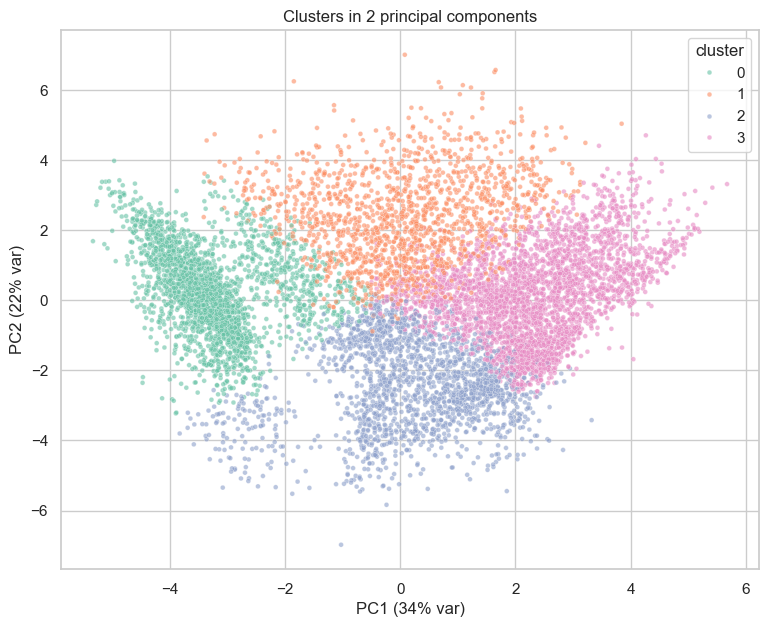

In [11]:
# PCA only to draw the clusters in 2D
pca = PCA(n_components=2, random_state=RANDOM_STATE)
coords = pca.fit_transform(X)
plt.figure(figsize=(9, 7))
sns.scatterplot(x=coords[:, 0], y=coords[:, 1], hue=df["cluster"],
                palette="Set2", s=12, alpha=.6)
plt.xlabel(f"PC1 ({pca.explained_variance_ratio_[0]*100:.0f}% var)")
plt.ylabel(f"PC2 ({pca.explained_variance_ratio_[1]*100:.0f}% var)")
plt.title("Clusters in 2 principal components"); plt.show()

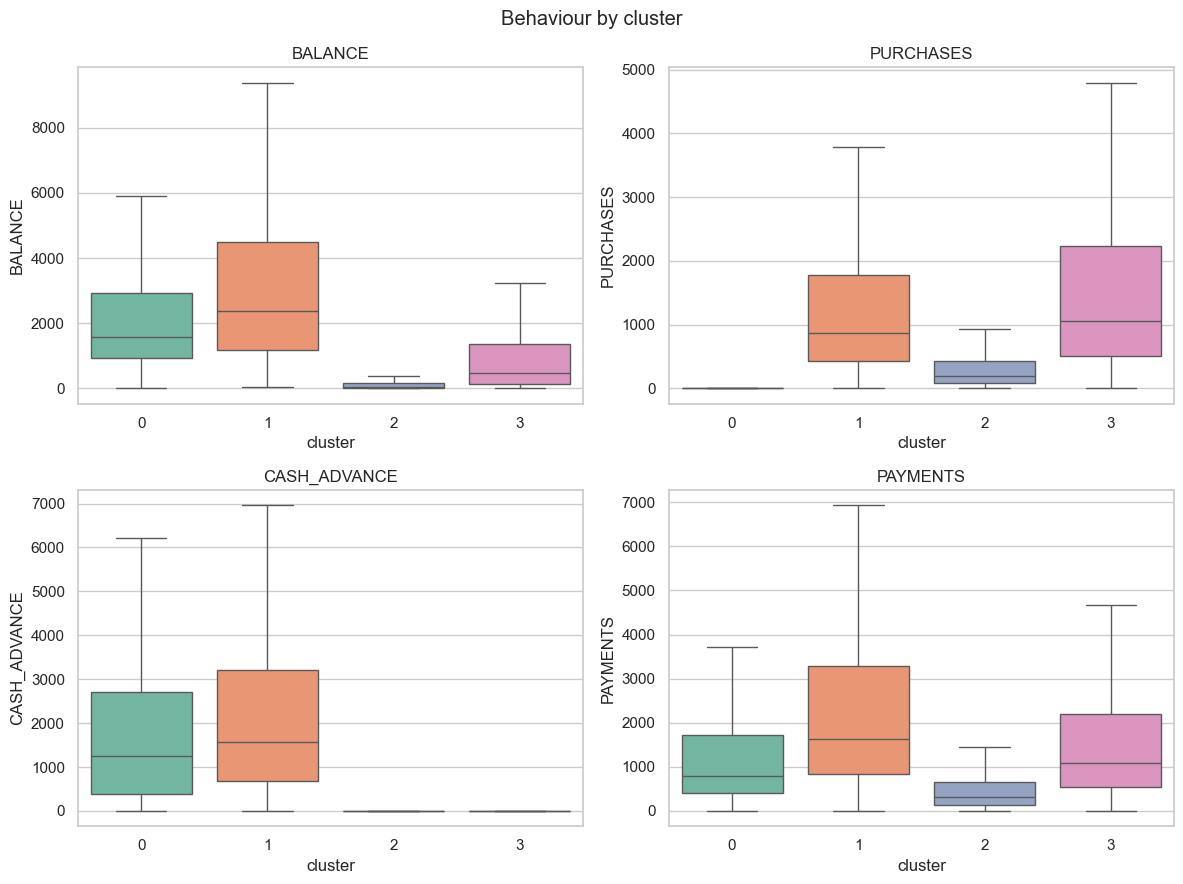

In [12]:
fig, axes = plt.subplots(2, 2, figsize=(12, 9))
for ax, col in zip(axes.ravel(), ["BALANCE", "PURCHASES", "CASH_ADVANCE", "PAYMENTS"]):
    sns.boxplot(x="cluster", y=col, hue="cluster", data=df, ax=ax,
                palette="Set2", showfliers=False, legend=False)
    ax.set_title(col)
fig.suptitle("Behaviour by cluster"); plt.tight_layout(); plt.show()

### Reading the four groups

(the cluster numbers are random each run, so I describe them by behaviour, not by the number.)

- **Cash-advance users (~27%)** - high balance, but almost no purchases. They mostly use the card to take cash, and they never pay the balance in full. This is expensive borrowing, a group to watch for risk.
- **High balance / heavy users (~17%)** - the highest balance, highest credit limit, they purchase a good amount *and* take a lot of cash advance, full payment rate is basically zero. The most credit exposure sits here.
- **Low activity / light users (~21%)** - very low balance, low purchases, almost no cash advance. The card is there but not really used. Big room to activate them.
- **Active responsible spenders (~35%)** - the biggest group. They purchase a lot and often, almost never use cash advance, and have the highest full-payment rate. These are the healthy, engaged customers.

## 7. Predict the cluster (supervised step)

Now I treat the cluster as a label and train a model to predict it from the features. Why - so a *new* customer can be put in a segment automatically, without re-running the clustering every time.

I split 70/30 (stratified so the group proportions stay the same) and train:

- a **Decision Tree** - not the most accurate, but you can read the rules, which is good when you have to explain it to non technical people.
- a **Random Forest** - usually more accurate but it is a black box.

In [13]:
y = df["cluster"]
X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.30, random_state=RANDOM_STATE, stratify=y)
print("train:", X_train.shape[0], " test:", X_test.shape[0])

tree = DecisionTreeClassifier(max_depth=5, min_samples_leaf=20, random_state=RANDOM_STATE)
tree.fit(X_train, y_train)
tree_pred = tree.predict(X_test)

forest = RandomForestClassifier(n_estimators=200, random_state=RANDOM_STATE, n_jobs=-1)
forest.fit(X_train, y_train)
forest_pred = forest.predict(X_test)

print(f"Decision Tree : accuracy {accuracy_score(y_test, tree_pred)*100:.2f}%  "
      f"kappa {cohen_kappa_score(y_test, tree_pred):.3f}")
print(f"Random Forest : accuracy {accuracy_score(y_test, forest_pred)*100:.2f}%  "
      f"kappa {cohen_kappa_score(y_test, forest_pred):.3f}")

train: 6265  test: 2685
Decision Tree : accuracy 92.22%  kappa 0.894
Random Forest : accuracy 96.42%  kappa 0.951


In [14]:
print(classification_report(y_test, tree_pred))

              precision    recall  f1-score   support

           0       0.94      0.96      0.95       724
           1       0.93      0.93      0.93       455
           2       0.83      0.91      0.87       572
           3       0.96      0.90      0.93       934

    accuracy                           0.92      2685
   macro avg       0.92      0.92      0.92      2685
weighted avg       0.92      0.92      0.92      2685



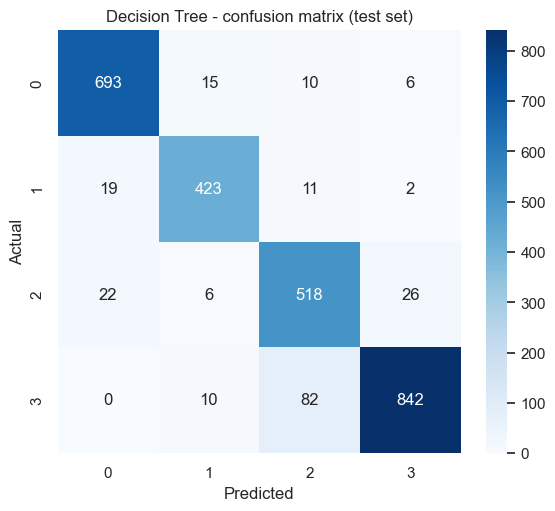

In [15]:
cm = confusion_matrix(y_test, tree_pred)
plt.figure(figsize=(6.5, 5.5))
sns.heatmap(cm, annot=True, fmt="d", cmap="Blues")
plt.xlabel("Predicted"); plt.ylabel("Actual")
plt.title("Decision Tree - confusion matrix (test set)"); plt.show()

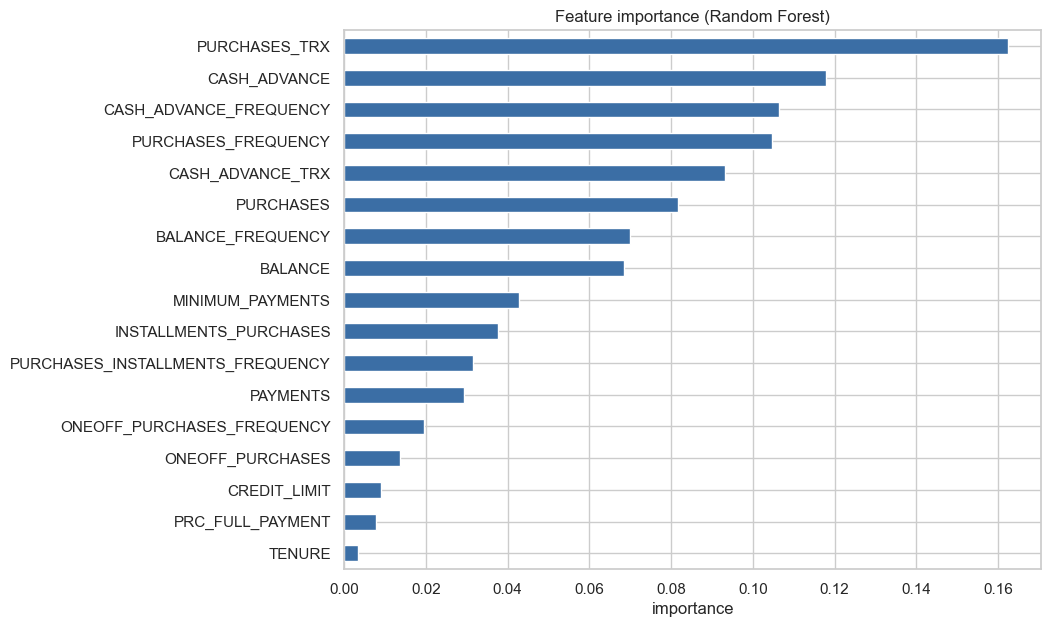

In [16]:
imp = pd.Series(forest.feature_importances_, index=features).sort_values()
plt.figure(figsize=(9, 7))
imp.plot(kind="barh", color="#3b6ea5")
plt.title("Feature importance (Random Forest)"); plt.xlabel("importance"); plt.show()

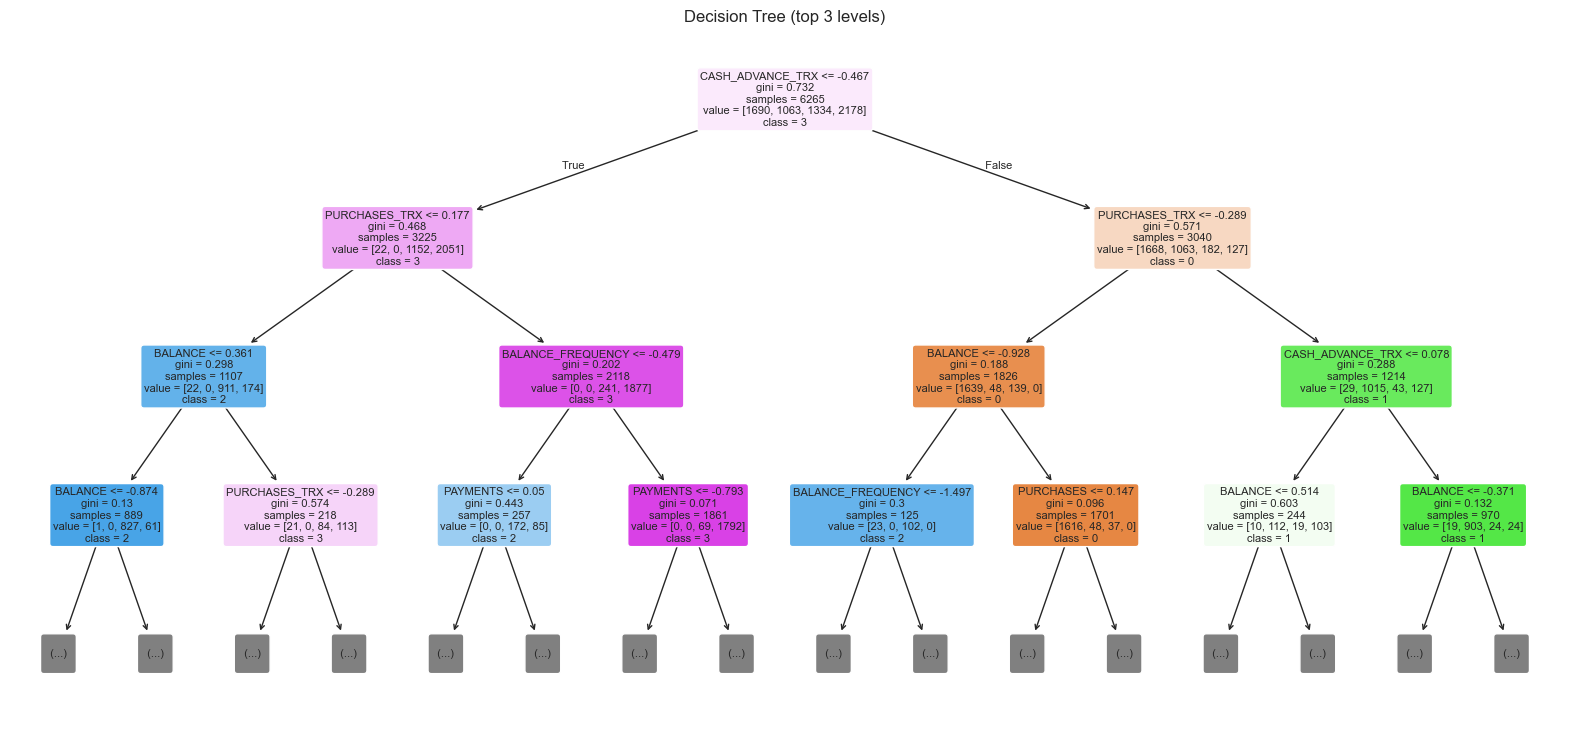

In [17]:
plt.figure(figsize=(20, 9))
plot_tree(tree, feature_names=features,
          class_names=[str(c) for c in sorted(y.unique())],
          filled=True, rounded=True, fontsize=8, max_depth=3)
plt.title("Decision Tree (top 3 levels)"); plt.show()

## 8. What I take from this

**On the modelling:**
- 4 groups is a reasonable choice (elbow + silhouette agree), and a second clustering method finds similar structure, so the segments are not just noise.
- The Decision Tree already reaches about **92%** accuracy on unseen data, and it is fully readable. The Random Forest goes higher (around **96%**) but you lose the simple explanation. For a business that needs to justify decisions, I would probably show the tree and keep the forest as a benchmark.
- The most important features for telling the groups apart are around **purchase activity** and **cash advance** behaviour, which matches the way I described the groups.

**Business side, what you could do with this:**
- the cash-advance / high-balance groups are where credit risk sits. They could be watched earlier with simple thresholds on cash advance and balance.
- the active responsible spenders are the healthy base, good target for loyalty / upsell.
- the low activity group is large and basically dormant, an activation campaign could move some of them into the active group.

**limitations:** the dataset has no outcome column (no default, no revenue), so all of this is descriptive. I am grouping behaviour, not predicting money directly. Also the cluster border between a couple of the groups is soft (you can see the overlap in the PCA plot), so the segments are useful as a guide, not as hard lines.